<a href="https://colab.research.google.com/github/Rut092/AI-Journey-Practice/blob/main/K_means_Clustering(lecture_11).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering

## Importing the Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## Importing the Dataset

In [4]:
dataset = pd.read_csv("Mall_Customers.csv")
print(dataset)

     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [6]:
X = dataset.iloc[:,[3,4]]
print(X)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


## Using Elbow Method to find the best number of Clusters(K)

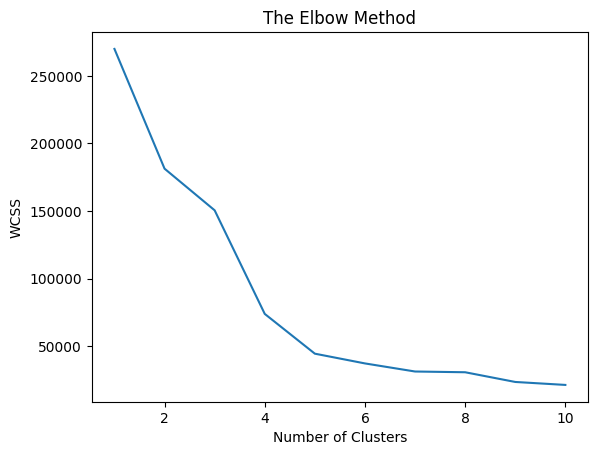

In [7]:
WCSS = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++',random_state=21)
    kmeans.fit(X)
    WCSS.append(kmeans.inertia_)


plt.plot(range(1,11),WCSS)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

## Training the K-Means Model

In [8]:
kmeans = KMeans(n_clusters = 5,init='k-means++',random_state=21)
y_kmeans = kmeans.fit_predict(X)
print(y_kmeans)

[2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2
 0 2 0 2 0 2 1 2 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 4 3 4 1 4 3 4 3 4 1 4 3 4 3 4 3 4 3 4 1 4 3 4 3 4
 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4]


## Plotting the Graph of the K-Means O/P

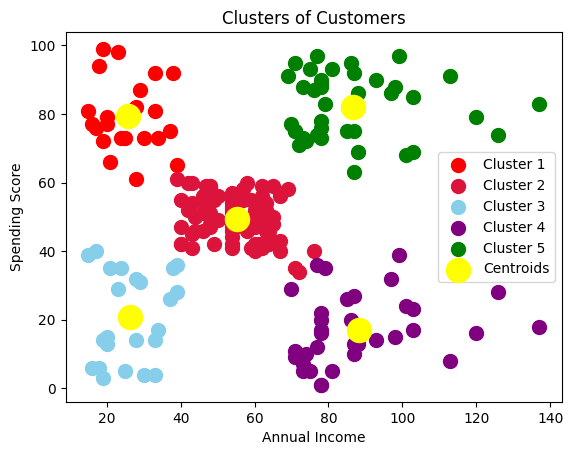

In [11]:
plt.scatter(X.iloc[y_kmeans==0,0],X.iloc[y_kmeans==0,1], c = 'red' , label = 'Cluster 1', s=100)
plt.scatter(X.iloc[y_kmeans==1,0],X.iloc[y_kmeans==1,1], c = 'crimson' , label = 'Cluster 2', s=100)
plt.scatter(X.iloc[y_kmeans==2,0],X.iloc[y_kmeans==2,1], c = 'skyblue' , label = 'Cluster 3', s=100)
plt.scatter(X.iloc[y_kmeans==3,0],X.iloc[y_kmeans==3,1], c = 'purple' , label = 'Cluster 4', s=100)
plt.scatter(X.iloc[y_kmeans==4,0],X.iloc[y_kmeans==4,1], c = 'green' , label = 'Cluster 5', s=100)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],c='yellow',label='Centroids', s=300)
plt.title('Clusters of Customers')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()